In [1]:
# Libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [2]:
# Load both datasets as .gpkg (both EPSG:2056)
gdf_zwn = gpd.read_file("data/data_zwn.gpkg")
gdf_qnr = gpd.read_file("data/data_qnr.gpkg", layer="stzh.adm_statistische_quartiere_v")
boundaries = gpd.read_file("data/data_qnr.gpkg", layer="stzh.adm_statistische_quartiere_v")

# Create copies of each dataset for manipulation
zwn = gdf_zwn.copy() # Züri wie neu dataframe
qnr = gdf_qnr.copy() # Zurich districts dataframe

In [3]:
# DATA CLEANING - on copies
# BEFORE SPATIAL JOIN. lots of useless columns/attributes

# Remove columns:       e.g. it's ~27k unique str. -> zwn["service_notice"].nunique() 
zwn = zwn.drop(columns={"service_notice", "objectid", "service_request_id", "service_code", "title", "detail", "media_url", "interface_used"})
qnr = qnr.drop(columns={"objid", "objectid"})

# Rename columns in ZWN
new_cols_zwn = {
    #"requested_datetime": "requested_datetime", 
    "agency_sent_datetime": "forwarded_datetime",
    "updated_datetime": "updated_datetime",
    "e": "easting",
    "n": "northing",
    "service_name": "CATEGORY"}
zwn = zwn.rename(columns=new_cols_zwn)

In [4]:
# Convert datetimes in ZWN (3 cols)
zwn["requested_datetime"] = pd.to_datetime(zwn["requested_datetime"])
zwn["forwarded_datetime"] = pd.to_datetime(zwn["forwarded_datetime"])
zwn["updated_datetime"]   = pd.to_datetime(zwn["updated_datetime"])

# New column: datetime of resolved issues
resolved_issues = ["fixed - council", ] # add others if needed!!
resolved_datetime = zwn["updated_datetime"].where(zwn["status"].isin(resolved_issues))
zwn["resolved_datetime"] = resolved_datetime

In [5]:
# Spatial join HOW=INNER, PREDICATE=WITHIN <- EXPLAIN!!
joined = gpd.sjoin(zwn, qnr, how="inner", predicate="within")

joined.head()

,requested_datetime,forwarded_datetime,updated_datetime,easting,northing,CATEGORY,status,userid,description,url,geometry,resolved_datetime,index_right,qname,qnr,kname,knr
0,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548),2013-04-12 07:59:30,16,Albisrieden,91,Kreis 9,9
1,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916),2013-04-12 08:00:22,20,Höngg,101,Kreis 10,10
2,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431),2013-04-12 08:08:10,33,Saatlen,121,Kreis 12,12
3,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376),2013-04-12 08:09:05,21,Wipkingen,102,Kreis 10,10
4,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762),2013-04-23 13:50:33,15,City,14,Kreis 1,1


In [6]:
# Time taken for an issue to be forwarded to the responsible department in the city administration
### days
joined["days_to_forward"] = (joined["forwarded_datetime"] - joined["requested_datetime"]).dt.days
avg_per_category_forwarded_d = joined.groupby("CATEGORY")["days_to_forward"].mean()

### hours
joined["hours_to_forward"] = (joined["forwarded_datetime"] - joined["requested_datetime"]).dt.total_seconds() / 3600 # = hours
avg_per_category_forwarded_h = joined.groupby("CATEGORY")["hours_to_forward"].mean()

print(f"Average DAYS taken to forward issue: \n\n{avg_per_category_forwarded_d.round(2)} \n\n{"_"*45}\n\nAverage HOURS taken to forward issue: \n\n{avg_per_category_forwarded_h.round(2)}")


Average DAYS taken to forward issue: 

CATEGORY
Abfall/Sammelstelle          0.18
Allgemein                    1.03
Beleuchtung/Uhren            0.46
Brunnen/Hydranten            0.27
Graffiti                     8.47
Grünflächen/Spielplätze      3.86
Schädlinge                   0.05
Signalisation/Lichtsignal    0.24
Strasse/Trottoir/Platz       1.84
VBZ/ÖV                       0.62
Name: days_to_forward, dtype: float64 

_____________________________________________

Average HOURS taken to forward issue: 

CATEGORY
Abfall/Sammelstelle            6.24
Allgemein                     36.04
Beleuchtung/Uhren             13.07
Brunnen/Hydranten              8.90
Graffiti                     210.35
Grünflächen/Spielplätze      106.08
Schädlinge                     1.82
Signalisation/Lichtsignal      8.40
Strasse/Trottoir/Platz        55.61
VBZ/ÖV                        18.42
Name: hours_to_forward, dtype: float64


__

**Graffiti** takes the longest time to be resolved, approx. **8.5 days**.

In [8]:
# Time taken for an issue to be resolved
joined["days_to_resolve"] = (joined["resolved_datetime"] - joined["requested_datetime"]).dt.days
avg_per_category_resolved_d = joined.groupby("CATEGORY")["days_to_resolve"].mean()

joined["hours_to_resolve"] = (joined["resolved_datetime"] - joined["requested_datetime"]).dt.total_seconds() / 3600 # = hours
avg_per_category_resolved_h = joined.groupby("CATEGORY")["hours_to_resolve"].mean()

print(f"Average DAYS taken to resolve issue: \n\n{avg_per_category_resolved_d.round(2)} \n\n{"_"*45}\n\nAverage HOURS taken to resolve issue: \n\n{avg_per_category_resolved_h.round(2)}")

## "Allgemein: 177 days on average"... let's check outliers
joined.groupby("CATEGORY")["days_to_resolve"].agg(["count", "median", "mean"])
    #    median is below mean -> right skew, meaning a minority of slow cases inflate the average.
    #       = typical resolution is 1-2 days, but a long tail of cases takes much longer
# remove Allgemein bc it is an undecisive category, and if im looking at categories then ...



Average DAYS taken to resolve issue: 

CATEGORY
Abfall/Sammelstelle            0.60
Allgemein                    177.00
Beleuchtung/Uhren              1.97
Brunnen/Hydranten              3.20
Graffiti                      12.58
Grünflächen/Spielplätze        4.33
Schädlinge                     0.60
Signalisation/Lichtsignal      4.37
Strasse/Trottoir/Platz         3.02
VBZ/ÖV                         2.90
Name: days_to_resolve, dtype: float64 

_____________________________________________

Average HOURS taken to resolve issue: 

CATEGORY
Abfall/Sammelstelle            24.07
Allgemein                    4266.92
Beleuchtung/Uhren              59.95
Brunnen/Hydranten              88.76
Graffiti                      314.53
Grünflächen/Spielplätze       117.75
Schädlinge                     25.44
Signalisation/Lichtsignal     114.77
Strasse/Trottoir/Platz         85.39
VBZ/ÖV                         80.95
Name: hours_to_resolve, dtype: float64


,count,median,mean
CATEGORY,,,
Abfall/Sammelstelle,26695,0.0,0.595243
Allgemein,1,177.0,177.000000
Beleuchtung/Uhren,5013,1.0,1.974865
Brunnen/Hydranten,1294,1.0,3.195518
Graffiti,3124,2.0,12.576504
Grünflächen/Spielplätze,6825,2.0,4.328938
Schädlinge,897,0.0,0.603122
Signalisation/Lichtsignal,10811,0.0,4.374526
Strasse/Trottoir/Platz,7534,1.0,3.019379


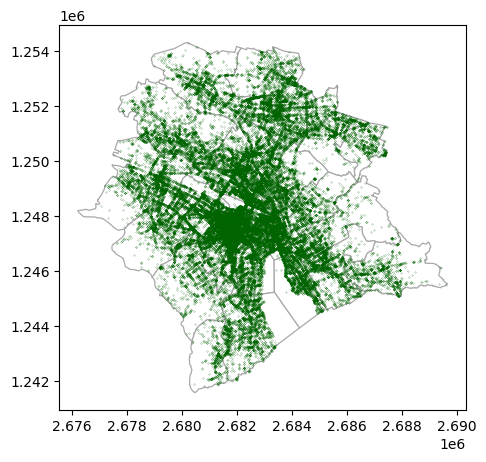

In [9]:
# BASIC SPATIAL PLOT
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the GeoDataFrame directly onto our specific Axes
boundaries.plot(ax=ax, color="white", edgecolor="darkgrey", lw=0.9)
# ADD TITLES AND AXES LABELS!!!!! better res??
joined.plot(ax=ax, markersize=0.1, marker=".", color="darkgreen")

plt.show()

In [43]:
# HEATMAP - shows clear cluster near
from folium import plugins

joined_wgs84 = joined.to_crs(epsg=4326) # needed for heatmap

map = folium.Map(location=[47.3769, 8.5417], tiles="Cartodb dark_matter", zoom_start=12)

heat_data = [[point.xy[1][0], point.xy[0][0]] for point in joined_wgs84.geometry]

plugins.HeatMap(
    heat_data,
    radius=10,        # smaller = more focused points (default 25)
    blur=10,           # smaller = sharper hotspots (default 15)
    min_opacity=0.3,  # hides the faint low-density haze
    max_zoom=13,      # intensity stops scaling past this zoom
    gradient={0.0: "navy", 0.25: "blue", 0.5: "lime", 0.75: "yellow", 1.0: "red"}
).add_to(map)

map